# Prédiction du score d'addiction à l'alcool
## Modèles de Machine Learning (comparaison et analyse) 

**Dataset :** Students-mat   
**Variable cible :** `Dalc` — Nombre de verres d'alcool par jour

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

In [1]:
#%pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score



from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBRegressor

## 2 - Chargement et preprocessing

On charge le dataset, séparons les données de la variable que l'on veut prédire et on convertit les variables textuelles en nombres avec `LabelEncoder` et `oneHotEncoder`.

Ensuite on sépare les données en 80% entraînement / 20% test.

In [2]:
from models.encoder import labelEncoder, oneHotEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

df = pd.read_csv('BDD_initial/student-mat.csv', sep=',', index_col=0)

y = df['Dalc']
# CORRECTION : drop simultané — avant 2 lignes séparées donc Walc restait dans X
X_raw = df.drop(columns=['Dalc', 'Walc'])

X_le  = labelEncoder(X_raw.copy())
X_ohe = oneHotEncoder(X_raw.copy())

# ACP — on sauvegarde scaler et pca séparément pour transformer un nouvel étudiant
acp_scaler = StandardScaler()
acp_pca    = PCA(n_components=20)
X_scaled   = acp_scaler.fit_transform(X_ohe)
x_acp      = acp_pca.fit_transform(X_scaled)

X_train_le,  X_test_le,  y_train_le,  y_test_le  = train_test_split(X_le,  y, test_size=0.2, random_state=42)
X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe = train_test_split(X_ohe, y, test_size=0.2, random_state=42)
X_train_acp, X_test_acp, y_train_acp, y_test_acp = train_test_split(x_acp, y, test_size=0.2, random_state=42)

cat_cols_le = df.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols_le:
    le = LabelEncoder()
    le.fit(df[col])
    label_encoders[col] = le

print('X_le  shape:', X_le.shape)
print('X_ohe shape:', X_ohe.shape)
print('x_acp shape:', x_acp.shape)
print('Train / Test:', X_train_le.shape[0], '/', X_test_le.shape[0])


X_le  shape: (395, 30)
X_ohe shape: (395, 55)
x_acp shape: (395, 20)
Train / Test: 316 / 79


C:\Users\sidsm\AppData\Local\Temp\ipykernel_22040\4160445921.py:24: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_le = df.select_dtypes(include='object').columns.tolist()


In [30]:
X_raw.columns

Index(['sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob',
       'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures',
       'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher',
       'internet', 'romantic', 'famrel', 'freetime', 'goout', 'health',
       'absences', 'G1', 'G2', 'G3'],
      dtype='str')

## 3. Entraînement des modèles

Chaque modèle est dans un fichier séparé dans `models/`.  
La fonction `run(X_train, X_test, y_train, y_test)` retourne un dictionnaire avec les métriques.

Tous les modèles sont présents en 2 versions : 
la version initial avec GridSearchCV est la meilleur mais peut prendre plusieurs minutes, la version 2 avec RandomizedSearchCV est plus courte mais moins précise. 

> **Pour ajouter un modèle** : importer sa fonction `run` et l'ajouter au dictionnaire `modeles`.

In [3]:

from models.random_forest_rgs_v2 import run as run_rf
from models.xgboost_rgs_v2 import run as run_xgb_rgs
from models.xgboost import run as run_xgb
from models.knn_rgs import run as run_knn
from models.naive_bayes_rgs_v2 import run as run_nb_rgs

modeles = {
    'KNN'          : run_knn,
    'xgboost rgs'  : run_xgb_rgs,
    'Naive Bayes rgs'  : run_nb_rgs,
    'XGBoost'      : run_xgb,
    'Random Forest': run_rf,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f'Entraînement : {nom}...')
    resultats[f'{nom} (LE)']  = run_fn(X_train_le,  X_test_le,  y_train_le, y_test_le)
    resultats[f'{nom} (OHE)'] = run_fn(X_train_ohe, X_test_ohe, y_train_ohe, y_test_ohe)
    resultats[f'{nom} (ACP)'] = run_fn(X_train_acp, X_test_acp, y_train_acp, y_test_acp)

    print(f"  LE  R²: {resultats[f'{nom} (LE)']['optimized']['r2']:.4f}")
    print(f"  OHE R²: {resultats[f'{nom} (OHE)']['optimized']['r2']:.4f}")
    print(f"  ACP R²: {resultats[f'{nom} (ACP)']['optimized']['r2']:.4f}")

print('\nTerminé.')


Entraînement : KNN...
  LE  R²: 0.0735
  OHE R²: -0.0363
  ACP R²: -0.1424
Entraînement : xgboost rgs...
  LE  R²: 0.0264
  OHE R²: 0.0104
  ACP R²: 0.0444
Entraînement : Naive Bayes rgs...
  LE  R²: -1.7675
  OHE R²: -7.9058
  ACP R²: 0.1685
Entraînement : XGBoost...
  LE  R²: -0.0130
  OHE R²: -0.0220
  ACP R²: 0.0326
Entraînement : Random Forest...
  LE  R²: -0.0283
  OHE R²: -0.0189
  ACP R²: 0.0293

Terminé.


In [4]:
from sklearn.ensemble import VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression

# 1. Extraction des vrais modèles (estimateurs Scikit-Learn) 
estimators_acp = [
    ('KNN', resultats['KNN (ACP)']['model']),
    ('xgb_rgs', resultats['xgboost rgs (ACP)']['model']),
    ('xgb', resultats['XGBoost (ACP)']['model']),
    ('rf', resultats['Random Forest (ACP)']['model'])
]

print('\nEntraînement des modèles d\'Ensemble...')

# 2. Voting Regressor (Fait la moyenne des prédictions)
model_voting = VotingRegressor(estimators=estimators_acp)

model_voting.fit(X_train_acp, y_train_acp) 
score_voting_acp = model_voting.score(X_test_acp, y_test_acp)

model_voting.fit(X_train_ohe, y_train_ohe) 
score_voting_ohe = model_voting.score(X_test_ohe, y_test_ohe)

model_voting.fit(X_train_le, y_train_le) 
score_voting_le = model_voting.score(X_test_le, y_test_le)

print(f"  Voting Regressor (ACP) R²: {score_voting_acp:.4f}")
print(f"  Voting Regressor (OHE) R²: {score_voting_ohe:.4f}")
print(f"  Voting Regressor (LE) R²: {score_voting_le:.4f}")

# 3. Stacking Regressor (Utilise un modèle final pour trancher)
model_stack = StackingRegressor(
    estimators=estimators_acp,
    final_estimator=LinearRegression(),
    cv=3 # Ajout de cv=3 pour accélérer l'entraînement interne
)
model_stack.fit(X_train_acp, y_train_acp)
score_stacking_acp = model_stack.score(X_test_acp, y_test_acp)

model_stack.fit(X_train_ohe, y_train_ohe) 
score_stacking_ohe = model_stack.score(X_test_ohe, y_test_ohe)

model_stack.fit(X_train_le, y_train_le) 
score_stacking_le = model_stack.score(X_test_le, y_test_le)

print(f"  Stacking Regressor (ACP) R²: {score_stacking_acp:.4f}")
print(f"  Stacking Regressor (OHE) R²: {score_stacking_ohe:.4f}")
print(f"  Stacking Regressor (LE) R²: {score_stacking_le:.4f}")


print('\nTerminé.')


Entraînement des modèles d'Ensemble...
  Voting Regressor (ACP) R²: 0.0200
  Voting Regressor (OHE) R²: 0.0238
  Voting Regressor (LE) R²: 0.0463
  Stacking Regressor (ACP) R²: -0.0750
  Stacking Regressor (OHE) R²: -0.0064
  Stacking Regressor (LE) R²: 0.0259

Terminé.


### 4 Entrainement d'une plus grande variété de modèles d'apprentissage


In [5]:

clf = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(clf, X_ohe, y, cv=5)
scores.mean()
print("Scores OHE : ", scores)
print(scores.mean())

clf = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(clf, X_le, y, cv=5)
scores.mean()
print("Scores LE : ", scores)
print(scores.mean())

clf = DecisionTreeRegressor(random_state=0)
scores = cross_val_score(clf, x_acp, y, cv=5)
scores.mean()
print("Scores ACP : ", scores)
print(scores.mean())

Scores OHE :  [-0.40254728 -0.67575758 -0.40105787 -1.49526216 -0.32315271]
-0.659555519285137
Scores LE :  [-0.69220378 -0.38848485 -0.76975731 -1.22078332 -0.27126437]
-0.6684987266380432
Scores ACP :  [-0.96661521 -1.05878788 -0.36418793 -1.22078332 -0.88095238]
-0.8982653433689703


Les modèles de régressions ne sont ici pas performant, particulièrement en comparaison avec les modèles de classifications. 

In [6]:
def nbr_estimator_model(model,n_estim=100):
    best = 0
    best_k=0
    for k in range (1,n_estim,1):
        model_train = model(n_estimators=k)
        model_train.fit(X_train_acp, y_train_acp)
        score = model_train.score(X_test_acp, y_test_acp)
        if(best<score):
            best=score
            best_k=k
    print("best : ",best_k,best)
    return [best_k,best]

In [9]:

modeles = {
    "decision_tree_regressor": DecisionTreeRegressor(),
    "XGBRegressor":XGBRegressor(),
    "decision_tree_classifier": DecisionTreeClassifier(),
    "random_forest_classifier": RandomForestClassifier(n_estimators=10, max_depth=3),
    "logistic_regression": LogisticRegression(max_iter=1000),
    "gaussian_nb": GaussianNB(),
    "sgd_classifier": SGDClassifier(),
    "knn_classifier": KNeighborsClassifier(n_neighbors=5),
    "bagging_classifier": BaggingClassifier(estimator=DecisionTreeClassifier())
}

best=None

score_Best=-np.inf
list_model_voting = []
for nom, model in modeles.items():
    model.fit(X_train_acp, y_train_acp)
    score_model = model.score(X_test_acp,y_test_acp)
    print(f"{nom} : {score_model:.4f}")
    if score_model >score_Best:
        Best=model
        score_Best=score_model
    if(score_model >0.5):
        list_model_voting.append((nom, model))
        
model_0 = VotingClassifier(list_model_voting,
                          voting='hard')
model_0.fit(X_train_acp, y_train_acp)
model_0.score(X_test_acp, y_test_acp)

model_stack = StackingClassifier(list_model_voting,
                             final_estimator=model_0)
model_stack.fit(X_train_acp, y_train_acp)
model_stack.score(X_test_acp, y_test_acp)

if(score_Best>model_0.score(X_train_acp, y_train_acp)):
    best=model_0
if(score_Best>model_stack.score(X_test_acp, y_test_acp)):
    best=model_stack
print(f"\n\nMeilleur modèle : {best.__class__.__name__} avec un score de {score_Best:.4f}\n\n")

decision_tree_regressor : -1.2167
XGBRegressor : -0.0665
decision_tree_classifier : 0.5443
random_forest_classifier : 0.7595
logistic_regression : 0.7089
gaussian_nb : 0.7468
sgd_classifier : 0.6329
knn_classifier : 0.7595
bagging_classifier : 0.6835


Meilleur modèle : StackingClassifier avec un score de 0.7595




c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. Tableau comparatif

On compare les modèles sur trois métriques :
- **R²** : proportion de variance expliquée (plus c'est proche de 1, mieux c'est)
- **MAE** : erreur moyenne en points de score
- **RMSE** : similaire au MAE, mais pénalise plus les grandes erreurs

In [10]:
rows = []
for nom, res in resultats.items():
    opt = res['optimized']
    rows.append({
        'Modèle': nom,
        'R²'    : round(opt['r2'],   4),
        'MAE'   : round(opt['mae'],  4),
        'RMSE'  : round(opt['rmse'], 4),
    })

df_comparaison = pd.DataFrame(rows).sort_values('R²', ascending=False).set_index('Modèle')
df_comparaison

,R²,MAE,RMSE
Modèle,,,
Naive Bayes rgs (ACP),0.1685,0.5114,0.7611
KNN (LE),0.0735,0.5331,0.8034
xgboost rgs (ACP),0.0444,0.6146,0.8159
XGBoost (ACP),0.0326,0.6136,0.8210
Random Forest (ACP),0.0293,0.6212,0.8223
xgboost rgs (LE),0.0264,0.6194,0.8236
xgboost rgs (OHE),0.0104,0.5983,0.8303
XGBoost (LE),-0.0130,0.6000,0.8401
Random Forest (OHE),-0.0189,0.6176,0.8425


## 5. Visualisation des métriques

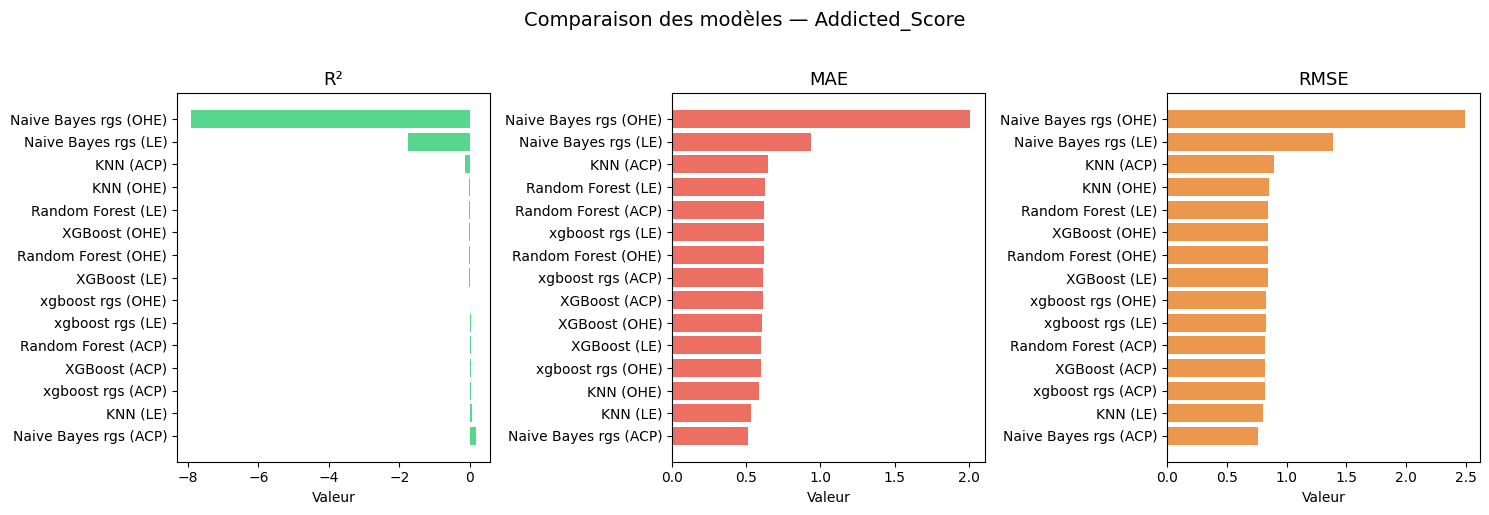

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('R²', '#2ecc71', False), ('MAE', '#e74c3c', True), ('RMSE', '#e67e22', True)]

for ax, (metric, color, ascending) in zip(axes, metrics):
    vals = df_comparaison[metric].sort_values(ascending=ascending)
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Valeur')

plt.suptitle('Comparaison des modèles — Addicted_Score', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Exemple d'application

On crée un profil d'étudiant fictif et on demande au modèle de prédire son score d'addiction.  
Les variables catégorielles sont encodées avec les mêmes `LabelEncoder` utilisés à l'étape 2.

In [12]:
etudiant = {
    'age': 17, 'Medu': 2, 'Fedu': 2, 'traveltime': 2,
    'studytime': 2, 'failures': 0, 'famrel': 4, 'freetime': 3,
    'goout': 3, 'health': 4, 'absences': 4,
    'G1': 11, 'G2': 11, 'G3': 11,
    'school': 'GP', 'sex': 'M', 'address': 'U', 'famsize': 'GT3',
    'Pstatus': 'T', 'Mjob': 'other', 'Fjob': 'other',
    'reason': 'course', 'guardian': 'mother', 'schoolsup': 'no',
    'famsup': 'yes', 'paid': 'no', 'activities': 'yes',
    'nursery': 'yes', 'higher': 'yes', 'internet': 'yes', 'romantic': 'no',
}

meilleur_cle = max(resultats, key=lambda k: resultats[k]['optimized']['r2'])
meilleur_r2  = resultats[meilleur_cle]['optimized']['r2']

etudiant_df = pd.DataFrame([etudiant])

etudiant_enc = {}
for col, val in etudiant.items():
    if col in label_encoders:
        try:
            etudiant_enc[col] = label_encoders[col].transform([val])[0]
        except ValueError:
            etudiant_enc[col] = 0
    else:
        etudiant_enc[col] = val

if '(LE)' in meilleur_cle:
    X_etudiant = pd.DataFrame([etudiant_enc])[X_le.columns]

elif '(OHE)' in meilleur_cle:
    etudiant_ohe_raw = oneHotEncoder(etudiant_df.copy())
    X_etudiant = etudiant_ohe_raw.reindex(columns=X_ohe.columns, fill_value=0)

else:  # cas ACP — CORRECTION : appliquer scaler puis pca fittés sur X_ohe
    etudiant_ohe_raw  = oneHotEncoder(etudiant_df.copy())
    X_etudiant_ohe    = etudiant_ohe_raw.reindex(columns=X_ohe.columns, fill_value=0)
    X_etudiant_scaled = acp_scaler.transform(X_etudiant_ohe)
    X_etudiant        = acp_pca.transform(X_etudiant_scaled)

score_predit = resultats[meilleur_cle]['model'].predict(X_etudiant)[0]

print('=== Profil etudiant ===')
for k, v in etudiant.items():
    print(f'  {k:<15} : {v}')
print(f'\n Modele : {meilleur_cle}  (R2 = {meilleur_r2:.4f})')
print(f' Score predit : {score_predit:.2f} / 5')
if score_predit >= 4:
    print('    -> Niveau eleve')
elif score_predit >= 3:
    print('    -> Niveau modere')
else:
    print('    -> Niveau faible')


=== Profil etudiant ===
  age             : 17
  Medu            : 2
  Fedu            : 2
  traveltime      : 2
  studytime       : 2
  failures        : 0
  famrel          : 4
  freetime        : 3
  goout           : 3
  health          : 4
  absences        : 4
  G1              : 11
  G2              : 11
  G3              : 11
  school          : GP
  sex             : M
  address         : U
  famsize         : GT3
  Pstatus         : T
  Mjob            : other
  Fjob            : other
  reason          : course
  guardian        : mother
  schoolsup       : no
  famsup          : yes
  paid            : no
  activities      : yes
  nursery         : yes
  higher          : yes
  internet        : yes
  romantic        : no

 Modele : Naive Bayes rgs (ACP)  (R2 = 0.1685)
 Score predit : 1.00 / 5
    -> Niveau faible


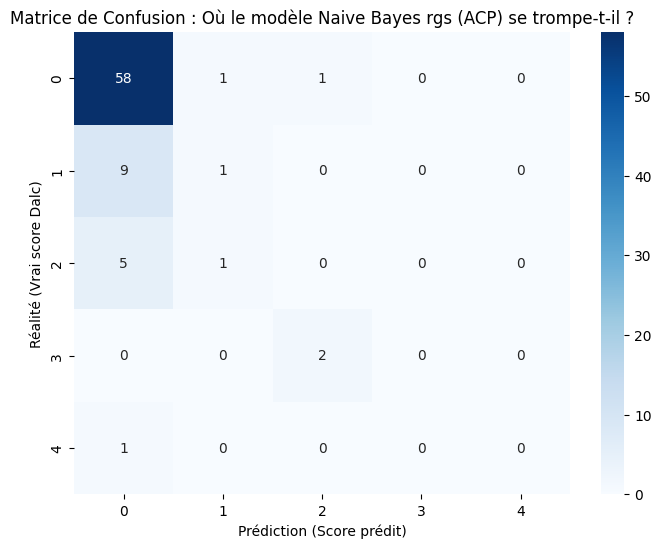

              precision    recall  f1-score   support

           1       0.79      0.97      0.87        60
           2       0.33      0.10      0.15        10
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         1

    accuracy                           0.75        79
   macro avg       0.23      0.21      0.21        79
weighted avg       0.65      0.75      0.68        79



c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\MAMP\htdocs\Addiction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Sélectionner les bonnes données de test selon le meilleur modèle trouvé
if '(LE)' in meilleur_cle:
    X_test_final = X_test_le
    y_test_final = y_test_le
elif '(OHE)' in meilleur_cle:
    X_test_final = X_test_ohe
    y_test_final = y_test_ohe
else:
    X_test_final = X_test_acp
    y_test_final = y_test_acp

# 2. Récupérer le meilleur modèle
best_model = resultats[meilleur_cle]['model']

# 3. Faire les prédictions sur TOUT le jeu de test (pas juste l'étudiant fictif)
y_pred_final = best_model.predict(X_test_final)

# Astuce : Si votre modèle est un régresseur, on arrondit les prédictions 
# pour pouvoir les classer dans la matrice de confusion (1, 2, 3...)
y_pred_classes = np.round(y_pred_final).astype(int)
y_test_classes = np.round(y_test_final).astype(int)

# 4. Création de la matrice de confusion
conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)

# 5. Affichage du graphique
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.ylabel('Réalité (Vrai score Dalc)')
plt.xlabel('Prédiction (Score prédit)')
plt.title(f'Matrice de Confusion : Où le modèle {meilleur_cle} se trompe-t-il ?')
plt.show()

# 6. Rapport de classification
print(classification_report(y_test_classes, y_pred_classes))

Cette matrice confirme les analyses que nous avons déjà effectuées dans le notebook de prévisualisation des données : notre jeu de donnée contient une grande majorité de valeur 0 et 1 pour la variable Dalc, ce qui fait que notre modèle atteint un score d'accuracy de 0.75 en prédisant presque uniquement des 0 et 1. 

## 7. Conclusion

Ce notebook compare les modèles de régression entraînés sur le dataset `student-mat`.  
Le meilleur modèle est sélectionné selon le R² le plus élevé et le MAE/RMSE les plus faibles.

**Pour intégrer un nouveau modèle :**
1. Créer `models/nom_du_modele.py` avec une fonction `run(X_train, X_test, y_train, y_test) -> dict`
2. La fonction doit retourner au minimum : `{'optimized': {'r2', 'mae', 'rmse'}, 'model': estimateur}`
3. Décommenter la ligne d'import correspondante dans la cellule 4

## 8. Sauvegarde du modele .pkl — Naive Bayes + ACP

Pipeline complet : OHE -> StandardScaler -> PCA(20 composantes) -> GaussianNB

Avantage : `pipeline.predict(X_raw)` applique tout automatiquement.
FastAPI n'a besoin d'aucun encodage manuel.


In [14]:
import joblib
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('BDD_initial/student-mat.csv', sep=',', index_col=0)

y     = df['Dalc']
X_raw = df.drop(columns=['Dalc', 'Walc'])  # toutes variables, sans les 2 cibles alcool

cat_cols_pkl = X_raw.select_dtypes(include='object').columns.tolist()
num_cols_pkl = X_raw.select_dtypes(exclude='object').columns.tolist()

print(f'Features utilisees : {len(X_raw.columns)} variables')
print(f'  Numeriques    : {num_cols_pkl}')
print(f'  Categorielles : {cat_cols_pkl}')

preprocessor_pkl = ColumnTransformer([
    ('num', 'passthrough', num_cols_pkl),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_pkl)
])

pipeline_nb = Pipeline([
    ('preprocessor', preprocessor_pkl),
    ('scaler',       StandardScaler()),
    ('pca',          PCA(n_components=20)),
    ('model',        GaussianNB())
])

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42
)

pipeline_nb.fit(X_train, y_train)

score_train = pipeline_nb.score(X_train, y_train)
score_test  = pipeline_nb.score(X_test,  y_test)
print(f'\nScore train : {score_train:.4f}')
print(f'Score test  : {score_test:.4f}')
print(f'Ecart       : {score_train - score_test:.4f}')

joblib.dump(pipeline_nb, 'model_alcohol.pkl')
print('\nModele sauvegarde : model_alcohol.pkl')
print('Ordre colonnes attendu :', num_cols_pkl + cat_cols_pkl)


Features utilisees : 30 variables
  Numeriques    : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3']
  Categorielles : ['sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

Score train : 0.7152
Score test  : 0.7215
Ecart       : -0.0063

Modele sauvegarde : model_alcohol.pkl
Ordre colonnes attendu : ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'health', 'absences', 'G1', 'G2', 'G3', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


C:\Users\sidsm\AppData\Local\Temp\ipykernel_22040\4271394824.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_pkl = X_raw.select_dtypes(include='object').columns.tolist()
